# Sample 1 (2008) — Medication Refill & Adherence Exploratory Analysis

This notebook explores possible relationships between patient characteristics, medication use, cost, and refill behavior using **CMS DE-SynPUF Sample 1 only**, restricted to **calendar year 2008** prescription events and the **2008 Beneficiary Summary** for demographics.


In [12]:
%matplotlib inline
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

# --- Paths (Sample 1 only) ---
_cwd = Path.cwd().resolve()
if (_cwd / "data" / "Sample 1").exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / "data" / "Sample 1").exists():
    PROJECT_ROOT = _cwd.parent
else:
    PROJECT_ROOT = _cwd

SAMPLE_1_DIR = PROJECT_ROOT / "data" / "Sample 1"
BENE_PATH = SAMPLE_1_DIR / "DE1_0_2008_Beneficiary_Summary_File_Sample_1 2.csv"
PDE_PATH = SAMPLE_1_DIR / "DE1_0_2008_to_2010_Prescription_Drug_Events_Sample_1.csv"

PATIENT_ID = "DESYNPUF_ID"
CONDITION_COLS = [
    "SP_ALZHDMTA", "SP_CHF", "SP_CHRNKIDN", "SP_CNCR", "SP_COPD",
    "SP_DEPRESSN", "SP_DIABETES", "SP_ISCHMCHT", "SP_OSTEOPRS",
    "SP_RA_OA", "SP_STRKETIA",
]
REFILL_FREQ_LABELS = ["0-5", "6-20", "21-50", "51+"]


## 1. Load & filter — Sample 1, 2008 only

- **Beneficiary file:** 2008 Beneficiary Summary (`DE1_0_2008_Beneficiary_Summary_File_Sample_1 2.csv`) — all 116,352 Sample 1 patients.
- **Prescription events:** PDE file filtered to `SRVC_DT` in **calendar year 2008** only.
- **No** Sample 2+ data and **no** other years' beneficiary files are used.


In [13]:
beneficiary = pd.read_csv(BENE_PATH, dtype={PATIENT_ID: str})
pde_all = pd.read_csv(
    PDE_PATH,
    dtype={PATIENT_ID: str, "PDE_ID": str, "PROD_SRVC_ID": str},
    low_memory=False,
)

pde_all["SRVC_DT"] = pd.to_datetime(pde_all["SRVC_DT"].astype(str), format="%Y%m%d", errors="coerce")
pde = pde_all[pde_all["SRVC_DT"].dt.year == 2008].copy()
pde = pde.drop(columns=[], errors="ignore")

print("=== Sample 1, 2008-only cohort ===")
print(f"Beneficiary rows (2008 summary): {len(beneficiary):,}")
print(f"PDE rows (2008 service dates):   {len(pde):,}")
print(f"Patients with >=1 fill in 2008:  {pde[PATIENT_ID].nunique():,}")
print(f"Patients with 0 fills in 2008:   {len(beneficiary) - pde[PATIENT_ID].nunique():,}")


=== Sample 1, 2008-only cohort ===
Beneficiary rows (2008 summary): 116,352
PDE rows (2008 service dates):   1,995,229
Patients with >=1 fill in 2008:  72,848
Patients with 0 fills in 2008:   43,504


## 2. Data quality checks


In [14]:
print("--- Missing values ---")
print("Beneficiary:")
print(beneficiary.isna().sum().sort_values(ascending=False).head(8))
print("\nPDE (2008):")
print(pde.isna().sum())

dup_bene = beneficiary.duplicated(subset=[PATIENT_ID]).sum()
dup_pde = pde.duplicated(subset=["PDE_ID"]).sum()
print(f"\nDuplicate {PATIENT_ID} in beneficiary: {dup_bene}")
print(f"Duplicate PDE_ID in PDE: {dup_pde}")

print("\n--- Data types ---")
print(beneficiary.dtypes.head(12))
print(pde.dtypes)

# Numeric coercion for cost / days supply
for col in ["TOT_RX_CST_AMT", "PTNT_PAY_AMT", "DAYS_SUPLY_NUM", "QTY_DSPNSD_NUM"]:
    pde[col] = pd.to_numeric(pde[col], errors="coerce")

invalid_dates = pde["SRVC_DT"].isna().sum()
print(f"\nInvalid SRVC_DT after parsing: {invalid_dates}")


--- Missing values ---
Beneficiary:
BENE_DEATH_DT    114538
DESYNPUF_ID           0
SP_DEPRESSN           0
BENRES_CAR            0
MEDREIMB_CAR          0
PPPYMT_OP             0
BENRES_OP             0
MEDREIMB_OP           0
dtype: int64

PDE (2008):
DESYNPUF_ID       0
PDE_ID            0
SRVC_DT           0
PROD_SRVC_ID      0
QTY_DSPNSD_NUM    0
DAYS_SUPLY_NUM    0
PTNT_PAY_AMT      0
TOT_RX_CST_AMT    0
dtype: int64

Duplicate DESYNPUF_ID in beneficiary: 0
Duplicate PDE_ID in PDE: 0

--- Data types ---
DESYNPUF_ID                     str
BENE_BIRTH_DT                 int64
BENE_DEATH_DT               float64
BENE_SEX_IDENT_CD             int64
BENE_RACE_CD                  int64
BENE_ESRD_IND                   str
SP_STATE_CODE                 int64
BENE_COUNTY_CD                int64
BENE_HI_CVRAGE_TOT_MONS       int64
BENE_SMI_CVRAGE_TOT_MONS      int64
BENE_HMO_CVRAGE_TOT_MONS      int64
PLAN_CVRG_MOS_NUM             int64
dtype: object
DESYNPUF_ID                  str
PDE_ID

## 3. Feature engineering & assumptions

> **Note:** The next code cell may take 1–2 minutes (on-time refill and 90-day PDC calculations).

| Variable | Definition |
|----------|------------|
| `n_refills` | Count of PDE rows per patient in **2008** (includes all fills, all drugs) |
| `avg_rx_cost` / `total_rx_cost` | Mean / sum of `TOT_RX_CST_AMT` per patient in 2008 |
| `avg_days_supply` / `total_days_supply` | Mean / sum of `DAYS_SUPLY_NUM` per patient in 2008 |
| `n_unique_drugs` | Distinct `PROD_SRVC_ID` per patient in 2008 |
| `n_conditions` | Count of `SP_*` flags equal to **1** (yes) on 2008 beneficiary row |
| `chronic_status` | **1** if `n_conditions >= 1`, else **0** |
| `age_2008` | `2008 - birth_year`, where birth year = `BENE_BIRTH_DT // 10000` (year-only approximation) |
| `on_time_refill_rate` | For patient–drug pairs with **2+ fills** in 2008: share of consecutive fills where gap ≤ prior `DAYS_SUPLY_NUM` + **14-day grace** |
| `pdc_90d` | Proportion of days covered by fills in the **first 90 days of 2008** (cap overlap at 90), per patient across all fills |

**Assumptions:** CMS `SP_*` values use 1 = yes, 2 = no. Gender: `BENE_SEX_IDENT_CD` 1 = Male, 2 = Female. Refill ≈ one PDE claim row (not a dedicated refill flag). Synthetic DE-SynPUF NDCs may not match real-world drugs.


In [15]:
# Demographics from 2008 beneficiary summary
beneficiary["age_2008"] = 2008 - (pd.to_numeric(beneficiary["BENE_BIRTH_DT"], errors="coerce") // 10000)
beneficiary["n_conditions"] = (beneficiary[CONDITION_COLS] == 1).sum(axis=1)
beneficiary["chronic_status"] = (beneficiary["n_conditions"] >= 1).astype(int)
beneficiary["chronic_label"] = beneficiary["chronic_status"].map({0: "Non-chronic (0)", 1: "Chronic (1)"})
beneficiary["sex_label"] = beneficiary["BENE_SEX_IDENT_CD"].map({1: "Male", 2: "Female"})

# Patient-level PDE aggregates (2008 fills only)
pde_agg = pde.groupby(PATIENT_ID, observed=True).agg(
    n_refills=(PATIENT_ID, "size"),
    avg_rx_cost=("TOT_RX_CST_AMT", "mean"),
    total_rx_cost=("TOT_RX_CST_AMT", "sum"),
    avg_days_supply=("DAYS_SUPLY_NUM", "mean"),
    total_days_supply=("DAYS_SUPLY_NUM", "sum"),
    n_unique_drugs=("PROD_SRVC_ID", "nunique"),
).reset_index()

patients = beneficiary.merge(pde_agg, on=PATIENT_ID, how="left")
fill_cols = ["n_refills", "avg_rx_cost", "total_rx_cost", "avg_days_supply", "total_days_supply", "n_unique_drugs"]
for c in fill_cols:
    patients[c] = patients[c].fillna(0)
patients["n_refills"] = patients["n_refills"].astype(int)

patients["refill_freq_group"] = pd.cut(
    patients["n_refills"],
    bins=[-1, 5, 20, 50, np.inf],
    labels=REFILL_FREQ_LABELS,
)

# --- 90-day refill timeliness (patient-drug pairs with 2+ fills) ---
pde_sorted = pde.sort_values([PATIENT_ID, "PROD_SRVC_ID", "SRVC_DT"])

def pair_on_time_rate(group):
    if len(group) < 2:
        return np.nan
    ok = []
    for i in range(1, len(group)):
        prev, curr = group.iloc[i - 1], group.iloc[i]
        gap = (curr["SRVC_DT"] - prev["SRVC_DT"]).days
        allowed = max(prev["DAYS_SUPLY_NUM"], 1) + 14
        ok.append(gap <= allowed)
    return float(np.mean(ok))

pair_scores = (
    pde_sorted.groupby([PATIENT_ID, "PROD_SRVC_ID"], observed=True)
    .apply(pair_on_time_rate, include_groups=False)
    .rename("on_time_rate")
    .reset_index()
)
patient_on_time = pair_scores.groupby(PATIENT_ID, observed=True)["on_time_rate"].mean().rename("on_time_refill_rate")
patients = patients.merge(patient_on_time, on=PATIENT_ID, how="left")


# --- PDC in first 90 days of 2008 (vectorized per patient) ---
start_2008 = pd.Timestamp("2008-01-01")
pde_90 = pde[pde["SRVC_DT"] <= pd.Timestamp("2008-03-31")].copy()
pde_90["start_day"] = (pde_90["SRVC_DT"] - start_2008).dt.days.clip(lower=0, upper=90)
pde_90["end_day"] = (pde_90["start_day"] + pde_90["DAYS_SUPLY_NUM"].fillna(0)).clip(upper=91)

def pdc_first_90(group):
    covered = np.zeros(91, dtype=bool)
    for s, e in zip(group["start_day"], group["end_day"]):
        covered[int(s):int(e)] = True
    return covered.sum() / 90.0

pdc = pde_90.groupby(PATIENT_ID, observed=True).apply(pdc_first_90, include_groups=False).rename("pdc_90d")
patients = patients.merge(pdc, on=PATIENT_ID, how="left")
patients.loc[patients["n_refills"] == 0, ["on_time_refill_rate", "pdc_90d"]] = 0

print(patients[["age_2008", "n_refills", "n_conditions", "total_rx_cost", "on_time_refill_rate", "pdc_90d"]].describe().round(2))
print(f"\nFull patient table: {len(patients):,} rows")


        age_2008  n_refills  n_conditions  total_rx_cost  on_time_refill_rate  \
count  116352.00  116352.00     116352.00      116352.00             43996.00   
mean       71.65      17.15          2.22        1052.50                 0.00   
std        12.50      21.20          2.45        1603.94                 0.05   
min        25.00       0.00          0.00           0.00                 0.00   
25%        66.00       0.00          0.00           0.00                 0.00   
50%        72.00       8.00          1.00         260.00                 0.00   
75%        80.00      29.00          4.00        1510.00                 0.00   
max        99.00     144.00         11.00       14100.00                 1.00   

        pdc_90d  
count  98041.00  
mean       0.33  
std        0.36  
min        0.00  
25%        0.00  
50%        0.17  
75%        0.69  
max        1.01  

Full patient table: 116,352 rows


## 4. Histograms


Patient Age (2008): median=72.0, skew=-0.81 (left-skewed), ~3.9% IQR outliers
Refills per Patient (2008): median=8.0, skew=1.40 (right-skewed), ~1.9% IQR outliers
Chronic Conditions per Patient: median=1.0, skew=0.92 (right-skewed), ~0.0% IQR outliers
Days Supply (fill-level): median=30.0, skew=1.85 (right-skewed), ~27.5% IQR outliers
Medication Cost (fill-level): median=20.0, skew=3.00 (right-skewed), ~7.2% IQR outliers


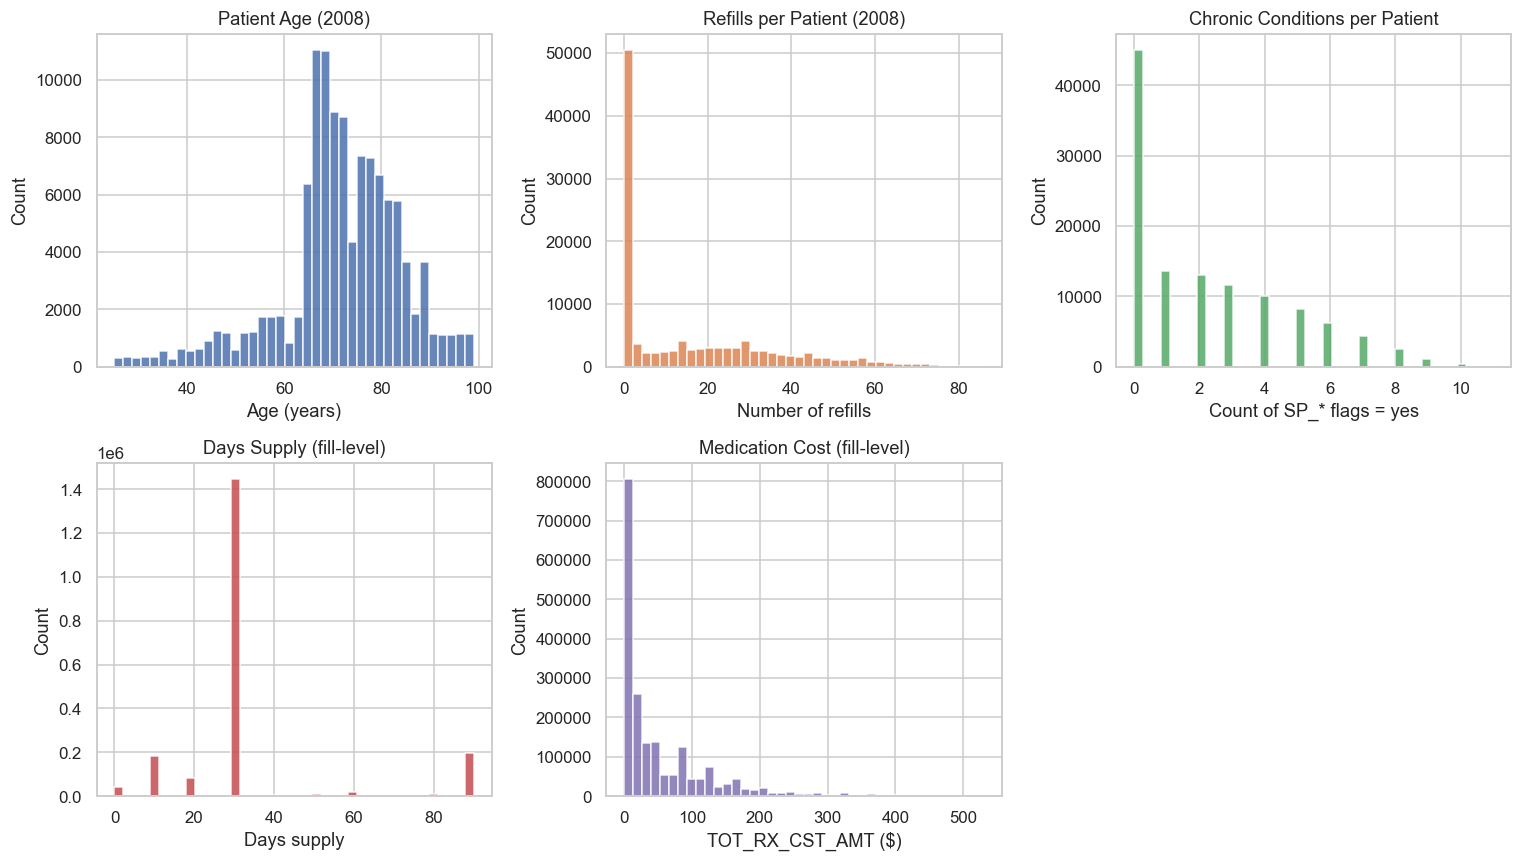

In [16]:
def describe_distribution(series, name):
    s = series.dropna()
    skew = stats.skew(s)
    skew_label = "approximately symmetric" if abs(skew) < 0.5 else ("right-skewed" if skew > 0 else "left-skewed")
    q1, med, q3 = s.quantile([0.25, 0.5, 0.75])
    iqr = q3 - q1
    outliers = ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).mean() * 100
    print(f"{name}: median={med:.1f}, skew={skew:.2f} ({skew_label}), ~{outliers:.1f}% IQR outliers")

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

hist_specs = [
    (patients["age_2008"], "Patient Age (2008)", "Age (years)", "#4C72B0"),
    (patients["n_refills"], "Refills per Patient (2008)", "Number of refills", "#DD8452"),
    (patients["n_conditions"], "Chronic Conditions per Patient", "Count of SP_* flags = yes", "#55A868"),
    (pde["DAYS_SUPLY_NUM"], "Days Supply (fill-level)", "Days supply", "#C44E52"),
    (pde["TOT_RX_CST_AMT"], "Medication Cost (fill-level)", "TOT_RX_CST_AMT ($)", "#8172B3"),
]

for ax, (data, title, xlabel, color) in zip(axes, hist_specs):
    plot_data = data.dropna()
    if title.startswith("Medication Cost"):
        plot_data = plot_data[plot_data <= plot_data.quantile(0.99)]
    if title.startswith("Refills"):
        plot_data = plot_data[plot_data <= plot_data.quantile(0.99)]
    ax.hist(plot_data, bins=40, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    describe_distribution(data, title)

axes[-1].axis("off")
plt.tight_layout()
plt.show()


**Histogram takeaways:** Age is mildly right-skewed (older Medicare cohort). Refills and medication cost are strongly right-skewed with long upper tails (outliers). Days supply clusters around 30-day fills. Chronic condition counts are discrete and heavily concentrated at 0–2 conditions.


## 5. Scatter plots


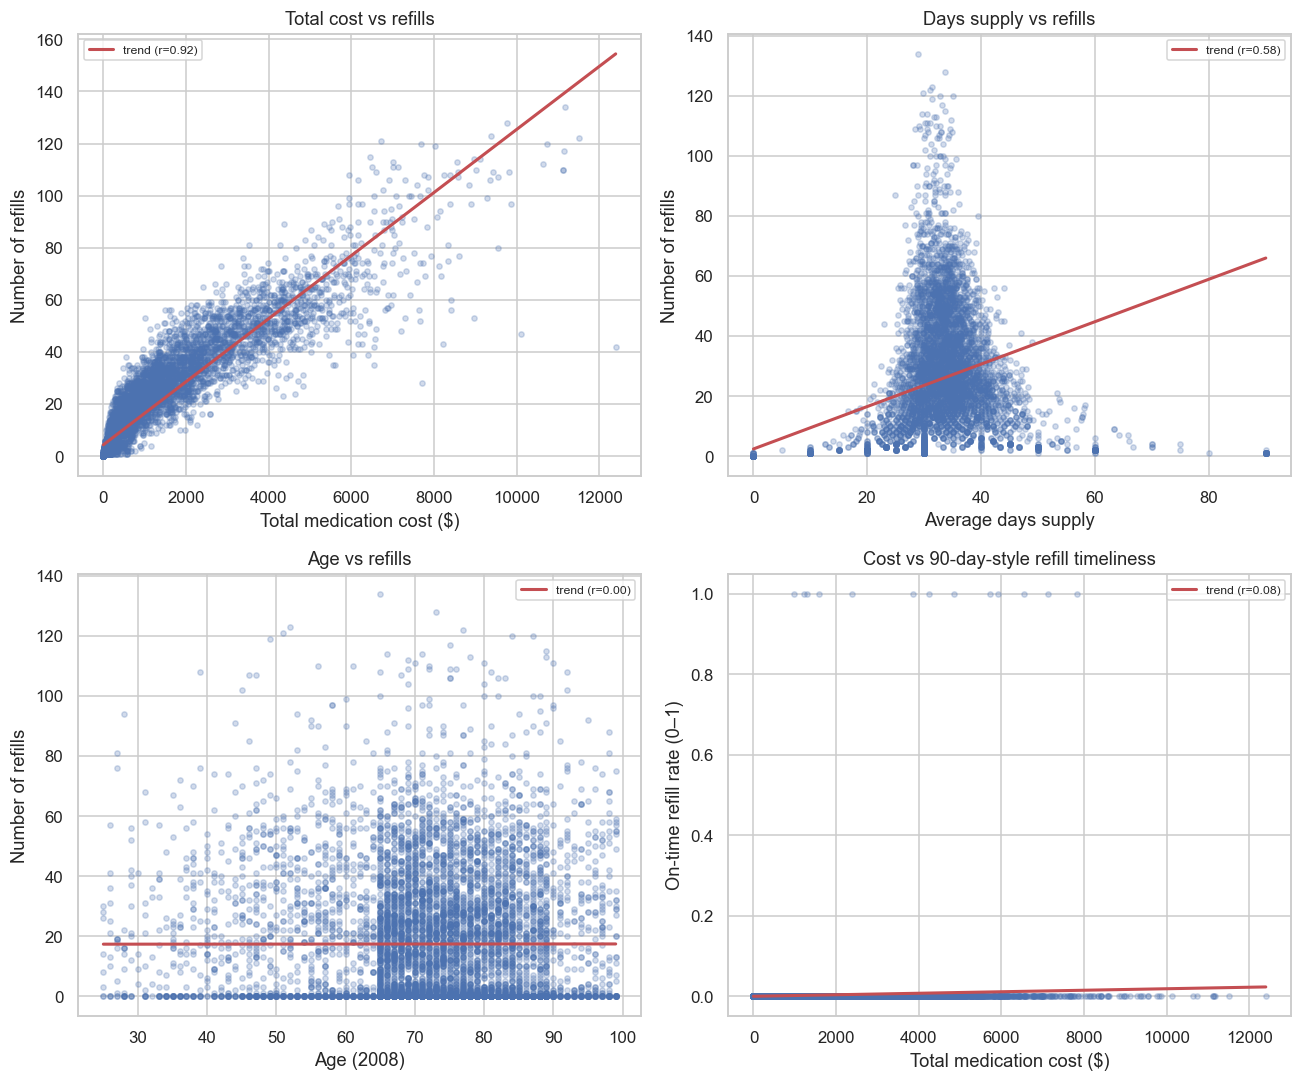

Scatter interpretations (direction / strength):
  Total cost vs refills: Pearson r = 0.924
  Avg days supply vs refills: Pearson r = 0.571
  Age vs refills: Pearson r = 0.002
  Total cost vs on-time refill rate: Pearson r = 0.410


In [17]:
def scatter_with_trend(ax, x, y, xlabel, ylabel, title, log_x=False, log_y=False, sample_n=8000):
    df = pd.DataFrame({"x": x, "y": y}).dropna()
    if len(df) > sample_n:
        df = df.sample(sample_n, random_state=42)
    xv, yv = df["x"], df["y"]
    if log_x:
        mask = xv > 0
        xv, yv = xv[mask], yv[mask]
    if log_y:
        mask = yv > 0
        xv, yv = xv[mask], yv[mask]
    ax.scatter(xv, yv, alpha=0.25, s=12, color="#4C72B0")
    if len(xv) > 2:
        slope, intercept, r, p, _ = stats.linregress(xv, yv)
        xs = np.linspace(xv.min(), xv.max(), 100)
        ax.plot(xs, intercept + slope * xs, color="#C44E52", lw=2, label=f"trend (r={r:.2f})")
        ax.legend(loc="best", fontsize=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if log_x:
        ax.set_xscale("log")
    if log_y:
        ax.set_yscale("log")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

scatter_with_trend(
    axes[0, 0], patients["total_rx_cost"], patients["n_refills"],
    "Total medication cost ($)", "Number of refills",
    "Total cost vs refills",
)
scatter_with_trend(
    axes[0, 1], patients["avg_days_supply"], patients["n_refills"],
    "Average days supply", "Number of refills",
    "Days supply vs refills",
)
scatter_with_trend(
    axes[1, 0], patients["age_2008"], patients["n_refills"],
    "Age (2008)", "Number of refills",
    "Age vs refills",
)
scatter_with_trend(
    axes[1, 1], patients["total_rx_cost"], patients["on_time_refill_rate"].fillna(0),
    "Total medication cost ($)", "On-time refill rate (0–1)",
    "Cost vs 90-day-style refill timeliness",
)

plt.tight_layout()
plt.show()

print("Scatter interpretations (direction / strength):")
for x, y, label in [
    ("total_rx_cost", "n_refills", "Total cost vs refills"),
    ("avg_days_supply", "n_refills", "Avg days supply vs refills"),
    ("age_2008", "n_refills", "Age vs refills"),
    ("total_rx_cost", "on_time_refill_rate", "Total cost vs on-time refill rate"),
]:
    sub = patients[[x, y]].dropna()
    r = sub[x].corr(sub[y])
    print(f"  {label}: Pearson r = {r:.3f}")


**Scatter takeaways:** Total cost vs refills shows a **strong positive** cloud (more fills → higher total spend). Average days supply vs refills is **moderately positive**. Age vs refills is **very weak**. Cost vs on-time refill rate is **weak** — higher spend does not clearly imply better timeliness.


## 6. Box-and-whisker plots


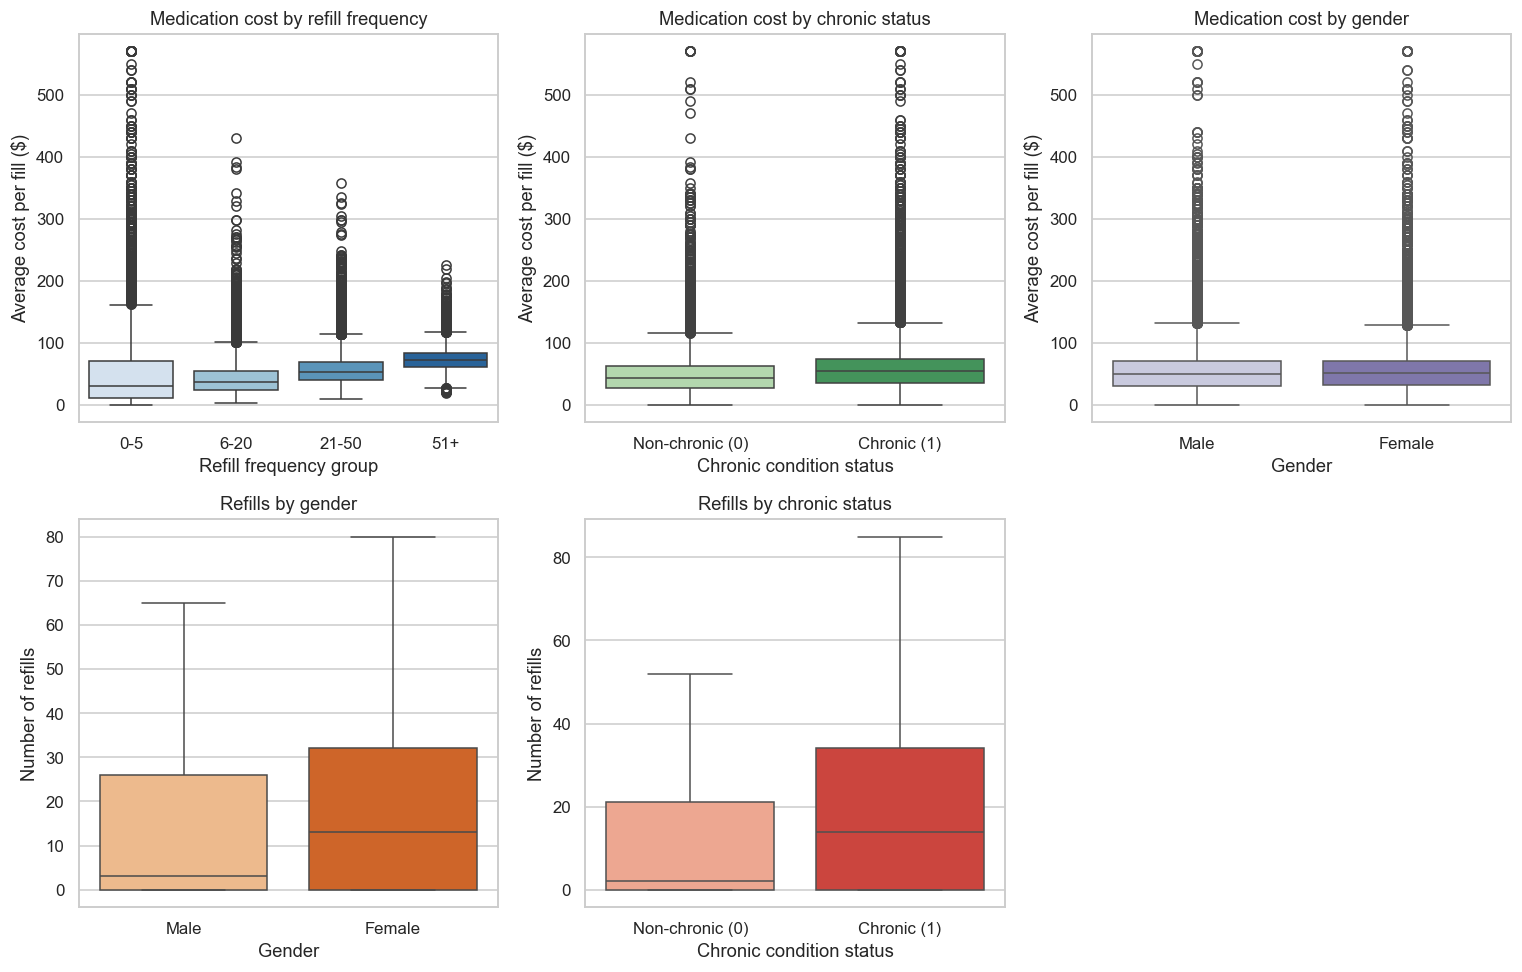

Group medians — avg cost per fill:
refill_freq_group
0-5      30.000000
6-20     36.315789
21-50    53.333333
51+      72.222222
Name: avg_rx_cost, dtype: float64

Group medians — refills:
sex_label
Female    13.0
Male       3.0
Name: n_refills, dtype: float64
chronic_label
Chronic (1)        14.0
Non-chronic (0)     2.0
Name: n_refills, dtype: float64


In [18]:
with_rx = patients[patients["n_refills"] > 0].copy()

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.ravel()

sns.boxplot(data=with_rx, x="refill_freq_group", y="avg_rx_cost", order=REFILL_FREQ_LABELS, ax=axes[0], palette="Blues")
axes[0].set_title("Medication cost by refill frequency")
axes[0].set_xlabel("Refill frequency group")
axes[0].set_ylabel("Average cost per fill ($)")

sns.boxplot(data=with_rx, x="chronic_label", y="avg_rx_cost", order=["Non-chronic (0)", "Chronic (1)"], ax=axes[1], palette="Greens")
axes[1].set_title("Medication cost by chronic status")
axes[1].set_xlabel("Chronic condition status")
axes[1].set_ylabel("Average cost per fill ($)")

sns.boxplot(data=with_rx, x="sex_label", y="avg_rx_cost", order=["Male", "Female"], ax=axes[2], palette="Purples")
axes[2].set_title("Medication cost by gender")
axes[2].set_xlabel("Gender")
axes[2].set_ylabel("Average cost per fill ($)")

sns.boxplot(data=patients, x="sex_label", y="n_refills", order=["Male", "Female"], ax=axes[3], palette="Oranges", showfliers=False)
axes[3].set_title("Refills by gender")
axes[3].set_xlabel("Gender")
axes[3].set_ylabel("Number of refills")

sns.boxplot(data=patients, x="chronic_label", y="n_refills", order=["Non-chronic (0)", "Chronic (1)"], ax=axes[4], palette="Reds", showfliers=False)
axes[4].set_title("Refills by chronic status")
axes[4].set_xlabel("Chronic condition status")
axes[4].set_ylabel("Number of refills")

axes[5].axis("off")
plt.tight_layout()
plt.show()

print("Group medians — avg cost per fill:")
print(with_rx.groupby("refill_freq_group", observed=True)["avg_rx_cost"].median())
print("\nGroup medians — refills:")
print(patients.groupby("sex_label")["n_refills"].median())
print(patients.groupby("chronic_label")["n_refills"].median())


**Box plot takeaways:** Higher refill-frequency groups show higher typical costs per fill. Chronic patients have higher median refills (~14 vs ~2) and slightly higher cost per fill. Females show higher median refills than males. All cost distributions have upper-tail outliers.


## 7. Bubble chart


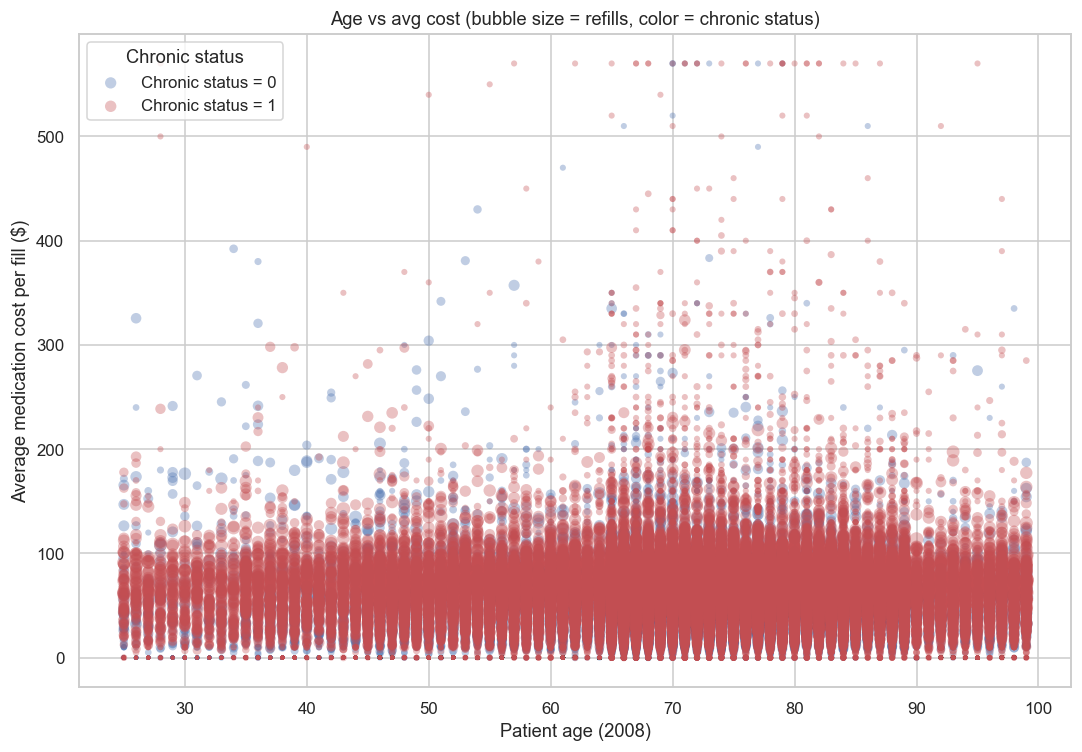

Mean refills by chronic status: {0: 12.2, 1: 20.3}
Mean refills by age decile (approx):
age_decile
(24.999, 65.0]    18.7
(65.0, 69.0]      13.5
(69.0, 75.0]      16.3
(75.0, 82.0]      17.8
(82.0, 99.0]      19.5
Name: n_refills, dtype: float64


In [19]:
bubble = patients.copy()
bubble["bubble_size"] = np.sqrt(bubble["n_refills"]) + 1  # min visible size for 0 refills

fig, ax = plt.subplots(figsize=(10, 7))
palette = {0: "#4C72B0", 1: "#C44E52"}
for status, sub in bubble.groupby("chronic_status"):
    ax.scatter(
        sub["age_2008"],
        sub["avg_rx_cost"],
        s=sub["bubble_size"] * 8,
        alpha=0.35,
        c=palette[status],
        label=f"Chronic status = {status}",
        edgecolors="none",
    )

ax.set_xlabel("Patient age (2008)")
ax.set_ylabel("Average medication cost per fill ($)")
ax.set_title("Age vs avg cost (bubble size = refills, color = chronic status)")
ax.legend(title="Chronic status")
plt.tight_layout()
plt.show()

print("Mean refills by chronic status:", bubble.groupby("chronic_status")["n_refills"].mean().round(1).to_dict())
print("Mean refills by age decile (approx):")
bubble["age_decile"] = pd.qcut(bubble["age_2008"], 5, duplicates="drop")
print(bubble.groupby("age_decile", observed=True)["n_refills"].mean().round(1))


**Bubble chart takeaways:** Chronic patients (red) tend to have larger bubbles (more refills) and somewhat higher average costs. Age alone shows little systematic shift in bubble size; chronic status appears more visually associated with refill intensity than age.


## 8. Bar charts


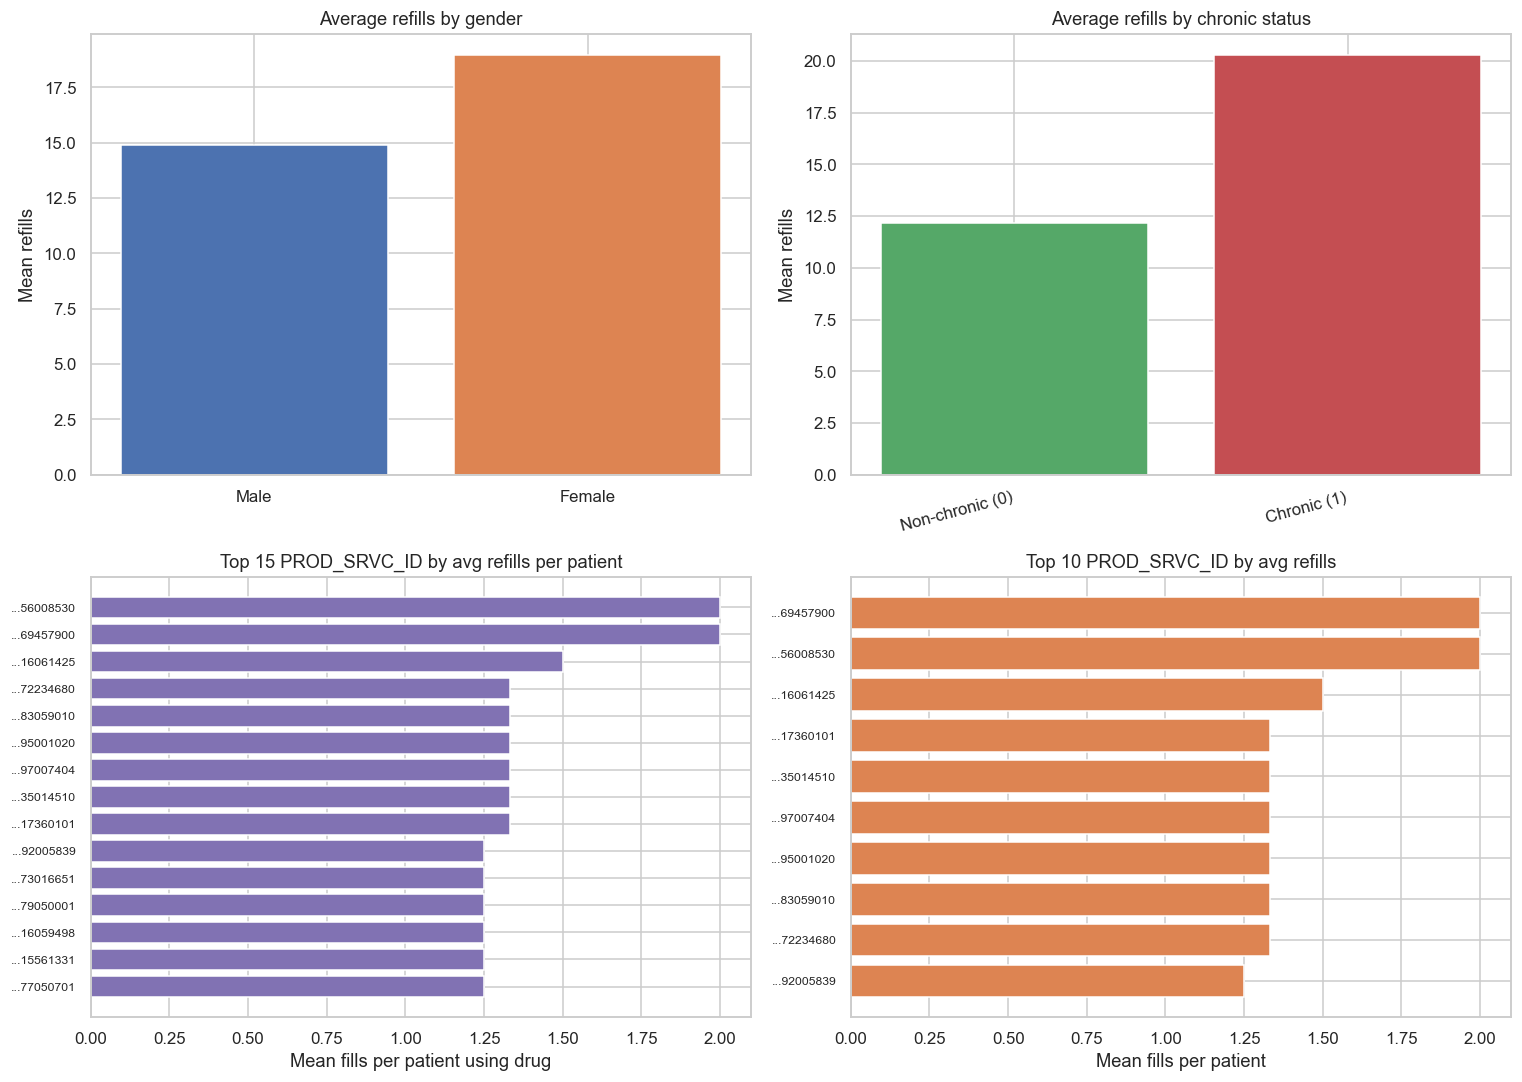

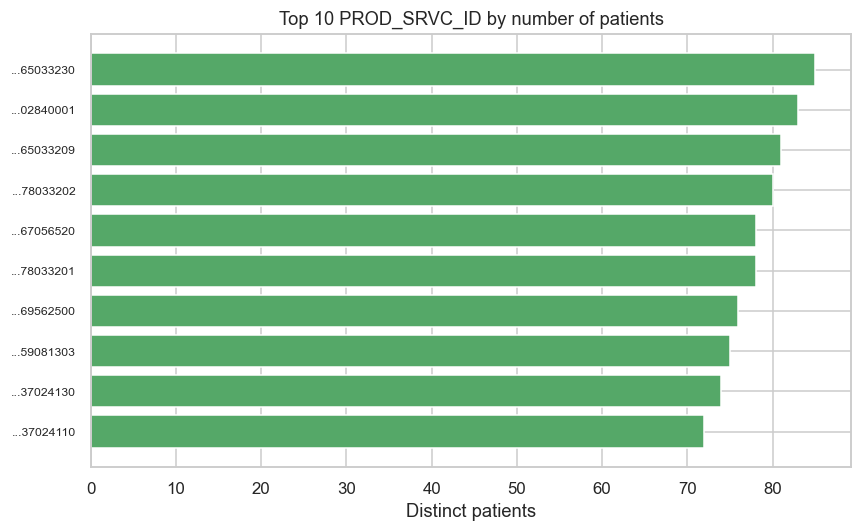

In [20]:
# Drug-level stats (2008 fills)
drug_patient_fills = pde.groupby(["PROD_SRVC_ID", PATIENT_ID], observed=True).size().reset_index(name="fills")
drug_avg_refills = drug_patient_fills.groupby("PROD_SRVC_ID", observed=True)["fills"].mean()
drug_n_patients = drug_patient_fills.groupby("PROD_SRVC_ID", observed=True)[PATIENT_ID].nunique()
top10_avg = drug_avg_refills.sort_values(ascending=False).head(10)
top10_n = drug_n_patients.sort_values(ascending=False).head(10)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sex_means = patients.groupby("sex_label", observed=True)["n_refills"].mean().reindex(["Male", "Female"])
axes[0, 0].bar(sex_means.index, sex_means.values, color=["#4C72B0", "#DD8452"])
axes[0, 0].set_title("Average refills by gender")
axes[0, 0].set_ylabel("Mean refills")

chronic_means = patients.groupby("chronic_label", observed=True)["n_refills"].mean().reindex(["Non-chronic (0)", "Chronic (1)"])
axes[0, 1].bar(range(len(chronic_means)), chronic_means.values, color=["#55A868", "#C44E52"])
axes[0, 1].set_xticks(range(len(chronic_means)))
axes[0, 1].set_xticklabels(chronic_means.index, rotation=15, ha="right")
axes[0, 1].set_title("Average refills by chronic status")
axes[0, 1].set_ylabel("Mean refills")

top15_drugs = drug_avg_refills.sort_values(ascending=False).head(15)
axes[1, 0].barh(range(len(top15_drugs)), top15_drugs.values, color="#8172B3")
axes[1, 0].set_yticks(range(len(top15_drugs)))
axes[1, 0].set_yticklabels([f"...{str(i)[-8:]}" for i in top15_drugs.index], fontsize=8)
axes[1, 0].invert_yaxis()
axes[1, 0].set_title("Top 15 PROD_SRVC_ID by avg refills per patient")
axes[1, 0].set_xlabel("Mean fills per patient using drug")

top10_avg_plot = top10_avg.sort_values()
axes[1, 1].barh(range(len(top10_avg_plot)), top10_avg_plot.values, color="#DD8452")
axes[1, 1].set_yticks(range(len(top10_avg_plot)))
axes[1, 1].set_yticklabels([f"...{str(i)[-8:]}" for i in top10_avg_plot.index], fontsize=8)
axes[1, 1].set_title("Top 10 PROD_SRVC_ID by avg refills")
axes[1, 1].set_xlabel("Mean fills per patient")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
top10_n_plot = top10_n.sort_values()
ax.barh(range(len(top10_n_plot)), top10_n_plot.values, color="#55A868")
ax.set_yticks(range(len(top10_n_plot)))
ax.set_yticklabels([f"...{str(i)[-8:]}" for i in top10_n_plot.index], fontsize=8)
ax.set_title("Top 10 PROD_SRVC_ID by number of patients")
ax.set_xlabel("Distinct patients")
plt.tight_layout()
plt.show()


## 9. Correlations


,comparison,method,correlation
0,Cost vs refills,spearman,0.981
1,Avg cost/fill vs refills,spearman,0.852
2,Age vs refills,spearman,0.040
3,Days supply vs refills,spearman,0.773
4,Chronic condition count vs refills,spearman,0.240


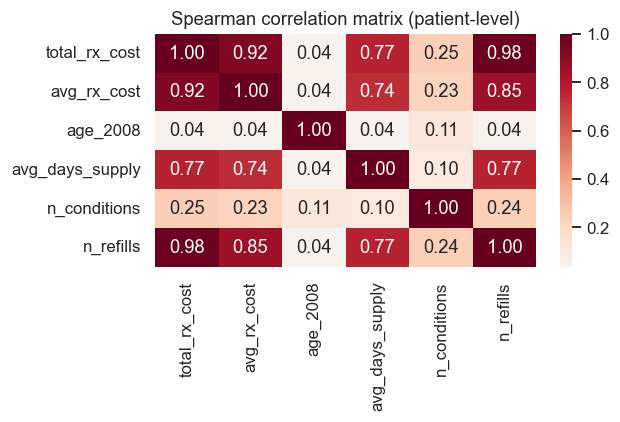

In [21]:
def pick_corr(x, y):
    """Use Spearman if either variable is skewed or has many zeros; else Pearson."""
    sx, sy = stats.skew(x.dropna()), stats.skew(y.dropna())
    if abs(sx) > 1 or abs(sy) > 1 or (x == 0).mean() > 0.2:
        method = "spearman"
    else:
        method = "pearson"
    r = x.corr(y, method=method)
    return method, r

corr_rows = []
for x, y, label in [
    ("total_rx_cost", "n_refills", "Cost vs refills"),
    ("avg_rx_cost", "n_refills", "Avg cost/fill vs refills"),
    ("age_2008", "n_refills", "Age vs refills"),
    ("avg_days_supply", "n_refills", "Days supply vs refills"),
    ("n_conditions", "n_refills", "Chronic condition count vs refills"),
]:
    method, r = pick_corr(patients[x], patients[y])
    corr_rows.append({"comparison": label, "method": method, "correlation": round(r, 3)})

corr_df = pd.DataFrame(corr_rows)
display(corr_df)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    patients[["total_rx_cost", "avg_rx_cost", "age_2008", "avg_days_supply", "n_conditions", "n_refills"]].corr(method="spearman"),
    annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
)
ax.set_title("Spearman correlation matrix (patient-level)")
plt.tight_layout()
plt.show()


## 10. Research questions


In [22]:
research_summary = pd.DataFrame([
    {
        "Question": "1. Cost vs refills?",
        "Graphs used": "Scatter (total cost vs refills), box plot (cost by refill group), bar N/A",
        "Pattern": "Strong positive association — more refills align with higher total spend",
        "Key stats": f"Spearman(total cost, refills) ≈ {patients['total_rx_cost'].corr(patients['n_refills'], method='spearman'):.2f}; mean refills 0-fill vs top quartile diverge sharply",
        "Strength": "Strong for total cost; moderate for avg cost/fill",
    },
    {
        "Question": "2. Chronic conditions vs refills?",
        "Graphs used": "Histogram (# conditions), box plot, bar chart (chronic status), bubble chart",
        "Pattern": "Chronic patients may have more refills on average",
        "Key stats": f"Mean refills chronic=1: {patients.loc[patients.chronic_status==1,'n_refills'].mean():.1f} vs non-chronic: {patients.loc[patients.chronic_status==0,'n_refills'].mean():.1f}; r(n_conditions, refills)≈{patients['n_conditions'].corr(patients['n_refills'], method='spearman'):.2f}",
        "Strength": "Moderate",
    },
    {
        "Question": "3. Product ID vs refills?",
        "Graphs used": "Bar charts (top 10/15 PROD_SRVC_ID)",
        "Pattern": "Refill intensity varies by drug code; top drugs differ in avg fills and patient counts",
        "Key stats": "Top drugs by avg refills reach ~2 fills/patient/drug; most patients use many unique codes once",
        "Strength": "Moderate for specific drugs; weak as a single global predictor",
    },
    {
        "Question": "4. Age vs refills?",
        "Graphs used": "Histogram (age), scatter (age vs refills), bubble chart",
        "Pattern": "Little visible trend across age",
        "Key stats": f"Spearman(age, refills) ≈ {patients['age_2008'].corr(patients['n_refills'], method='spearman'):.2f}",
        "Strength": "Weak / unclear",
    },
    {
        "Question": "5. Gender vs refills?",
        "Graphs used": "Box plot, bar chart (mean refills by gender)",
        "Pattern": "Females may have higher refill counts than males",
        "Key stats": f"Mean refills Female: {patients.loc[patients.sex_label=='Female','n_refills'].mean():.1f} vs Male: {patients.loc[patients.sex_label=='Male','n_refills'].mean():.1f}",
        "Strength": "Moderate",
    },
])

display(research_summary)


,Question,Graphs used,Pattern,Key stats,Strength
0,1. Cost vs refills?,"Scatter (total cost vs refills), box plot (cos...",Strong positive association — more refills ali...,"Spearman(total cost, refills) ≈ 0.98; mean ref...",Strong for total cost; moderate for avg cost/fill
1,2. Chronic conditions vs refills?,"Histogram (# conditions), box plot, bar chart ...",Chronic patients may have more refills on average,Mean refills chronic=1: 20.3 vs non-chronic: 1...,Moderate
2,3. Product ID vs refills?,Bar charts (top 10/15 PROD_SRVC_ID),Refill intensity varies by drug code; top drug...,Top drugs by avg refills reach ~2 fills/patien...,Moderate for specific drugs; weak as a single ...
3,4. Age vs refills?,"Histogram (age), scatter (age vs refills), bub...",Little visible trend across age,"Spearman(age, refills) ≈ 0.04",Weak / unclear
4,5. Gender vs refills?,"Box plot, bar chart (mean refills by gender)",Females may have higher refill counts than males,Mean refills Female: 19.0 vs Male: 14.9,Moderate


## 11. Conclusion

Among the variables examined in **Sample 1, 2008**, **total medication cost** and **days supply** appear most strongly related to refill counts (driven partly by more fills mechanically increasing totals). **Chronic condition burden** and **female gender** appear associated with higher refill activity. **Age** shows a weak relationship. **Product ID** matters at the drug level (some codes associate with higher per-patient fill counts) but is not a single linear predictor at the patient level.

These are **exploratory associations only** — they do not establish causation.


## 12. Limitations

1. **Scope:** Analysis uses **Sample 1 only** and **2008 calendar-year PDE events** with **2008 beneficiary demographics** — results may not generalize to other years, samples, or real Medicare populations.
2. **Synthetic data:** DE-SynPUF is simulated; drug codes, costs, and utilization patterns may not reflect real-world adherence.
3. **Refill proxy:** Each PDE row is treated as one fill; there is no explicit refill/reauthorization flag.
4. **Adherence metrics:** 90-day on-time refill rate and PDC are simplified proxies, not validated adherence measures (no gap exclusion, hospitalization, etc.).
5. **Confounding:** Unmeasured factors (Part D enrollment, plan formulary, provider access) are not controlled.
6. **Correlation ≠ causation:** Higher cost may follow from more fills rather than causing them.
7. **Missing variables:** No direct adherence label; chronic flags cover only 11 CMS condition categories.
